# **1. Konsep Dasar Integral**

Secara matematis, integral tertentu

$$ I = \int_{a}^{b} f(x) \ dx$$

dapat dipahami sebagai luas bertanda di bawah kurva $f(x)$ dari $a$ sampai $b$

Misalnya kita mempunyai

$$ f(x) = x^2 $$

dan ingin menghitung

$$ I = \int_{0}^{2} x^2 \ dx $$

Secara analitik:

$$ I = \left[ \frac{x^3}{3} \right]_0^2 $$

sehingga

$$ I = \frac{8}{3} \approx 2.6667. $$

Nilai ini dapat kita gunakan sebagai **nilai referensi** untuk menguji metode numerik.

# **2. Mengapa Kita Membutuhkan Integral Numerik?**

Integral analitik tidak selalu mudah dilakukan.

Contohnya:

$$\int e^{-x^2} \, dx$$

tidak memiliki bentuk antiturunan elementer sederhana.

Dalam fisika, bahkan sering muncul integral yang jauh lebih kompleks:

$$I = \int_a^b f(x, y, z) e^{-V(x,y,z)/k_B T} \, dx \, dy \, dz.$$

Dalam situasi seperti ini, komputer dapat digunakan untuk memperoleh pendekatan numerik.

Secara umum:

$$\boxed{\text{Integral numerik} \approx \text{penjumlahan sejumlah luas kecil}}$$

# **3. Ide Dasar Integral Numerik**

Interval

$$[a, b]$$

dibagi menjadi $N$ subinterval.

Lebar setiap subinterval:

$$h = \frac{b - a}{N}.$$

Misalnya:

$$a = 0, \quad b = 2, \quad N = 4.$$

Maka

$$h = \frac{2 - 0}{4} = 0.5.$$

Titik-titiknya:

$$x_0 = 0$$
$$x_1 = 0.5$$
$$x_2 = 1$$
$$x_3 = 1.5$$
$$x_4 = 2.$$

Integral kemudian didekati menggunakan bentuk-bentuk geometri sederhana.

# **4. Rectangle Rule**

Metode paling sederhana adalah menanggap setiap bagian kurva sebagai persegi panjang.

Secara umum:

$$I \approx \sum_{i=0}^{N-1} f(x_i)h.$$

---

### 5.1 Left Rectangle Rule

Kita menggunakan titik sebelah kiri setiap interval.

$$I_L = h \sum_{i=0}^{N-1} f(x_i)$$

dengan

$$x_i = a + ih.$$

**Contoh**

Hitung:

$$I = \int_0^2 x^2 \, dx$$

dengan $N = 4$.

Nilai $x$:

$$0, \, 0.5, \, 1, \, 1.5.$$

Nilai fungsi:

$$0, \, 0.25, \, 1, \, 2.25.$$

Sehingga:

$$I_L = 0.5(0 + 0.25 + 1 + 2.25)$$

$$I_L = 1.75.$$

Nilai eksak:

$$I = 2.6667.$$

Jadi errornya cukup besar.

In [1]:
def left_rectangle(f, a, b, N):
    h = (b - a) / N

    total = 0.0

    for i in range(N):
        x = a + i * h
        total += f(x)

    return h * total

In [2]:
def f(x):
    return x**2

a = 0
b = 2
N = 4

hasil = left_rectangle(f, a, b, N)

print(f"Hasil = {hasil}")

Hasil = 1.75


### 5.2 Right Rectangle Rule

Kali ini kita menggunakan titik sebelah kanan.

$$ I_R = h \sum_{i=1}^{N} f(x_i) $$

dengan 

$$ x_i = a + ih $$

Implementasi:

In [3]:
def right_rectangle(f, a, b, N):
    h = (b - a) / N

    total = 0.0

    for i in range(1, N+1):
        x = a + i * h
        total += f(x)
    
    return h * total

In [4]:
hasil = right_rectangle(f, a, b, N)

print(hasil)

3.75


Menariknya:  
* Left Rectangle: terlalu kecil  
* Right Rectangle: terlalu besar  

Hal ini terjadi karena $x^2$ merupakan fungsi yag meningkat pada interval tersebut.

## **6. Midpoint Rule**

Metode Midpoint menggunakan titik tengah setiap interval.

Titik tengah:

$$ x_{i + \frac{1}{2}} = a + \left(i + \frac{1}{2}\right) h $$

Integral:

$$\boxed{I_M \approx h \sum_{i=0}^{N-1} f\left(a + \left(i + \frac{1}{2}\right)h\right)}$$

Metode ini biasanya lebih akurat daripada menggunakan titik kiri atau kanan.

In [5]:
def midpoint_rule(f, a, b, N):
    h = (b - a) / N

    total = 0.0

    for i in range(N):
        x_mid = a + (i + 0.5) * h
        total += f(x_mid)
    
    return h * total

In [6]:
hasil = midpoint_rule(f, a, b, N)

print(f"Hasil = {hasil}")

Hasil = 2.625


Nilai eksak:

$$ 2.6666667 $$

Sehingga Midpoint Rule jauh lebih baik daripada Left Rectangle.

# **7. Trapezoidal Rule**

Trapezoidal Rule menggunakan trapesium untuk mendekati kurva.

Luas trapesium:

$$A_i = \frac{f(x_i) + f(x_{i+1})}{2} h.$$

Jika semua interval dijumlahkan:

$$I_T = \frac{h}{2} \left[ f(x_0) + 2 \sum_{i=1}^{N-1} f(x_i) + f(x_N) \right].$$

Jadi:

$$\boxed{I_T = \frac{h}{2} \left[ f(a) + f(b) + 2 \sum_{i=1}^{N-1} f(x_i) \right]}$$

In [7]:
def trapezoidal_rule(f, a, b, N):
    h = (b - a) / N

    total = f(a) + f(b)

    for i in range(1, N):
        x = a + i * h
        total += 2 * f(x)
    
    return (h / 2) * total

In [8]:
hasil = trapezoidal_rule(f, a, b, N)

print(f"Hasil = {hasil}")

Hasil = 2.75


Untuk fungsi yang cukup halus, error truncation Trapezoidal Rule memiliki orde:

$$O(h^2).$$

Artinya:

$$E_T \propto h^2.$$

Karena

$$h = \frac{b - a}{N},$$

maka:

$$E_T \propto \frac{1}{N^2}.$$

Artinya jika jumlah interval dinaikkan:

$$N \rightarrow 2N$$

maka error kira-kira menjadi:

$$\frac{1}{4}$$

dari error sebelumnya.

Ini merupakan konsep yang sangat penting dalam metode numerik.

# **8. Simpson's Rule**

Simpson's Rule memberikan pendekatan yang lebih baik dengan menggunakan **polinom orde dua**

Alih-alih mengaproksimasi kurva dengan garis lurus seperti Trapezoidal Rule, Simpson menggunakan parabola.

Untuk dua interval:

$$x_0, \, x_1, \, x_2$$

diperoleh:

$$\boxed{\int_{x_0}^{x_2} f(x) \, dx \approx \frac{h}{3} [f(x_0) + 4f(x_1) + f(x_2)]}$$

Jika terdapat $N$ interval, $N$ harus **genap**.

Formula komposit:

$$\boxed{I_S = \frac{h}{3} \left[ f(x_0) + 4 \sum_{\text{indeks ganjil}} f(x_i) + 2 \sum_{\text{indeks genap}} f(x_i) + f(x_N) \right]}$$

In [9]:
def simpson_rule(f, a, b, N):
    if N % 2 != 0:
        raise ValueError("N harus genap untuk Simpson's Rule")
    
    h = (b - a) / N

    total = f(a) + f(b)

    for i in range(1, N):
        x = a + i * h

        if i % 2 == 0:
            total += 2 * f(x)

        else:
            total += 4 * f(x)
    
    return (h / 3) * total

In [10]:
hasil = simpson_rule(f, a, b, N)

print(f"Hasil = {hasil}")

Hasil = 2.6666666666666665


Perhatikan orde error:

<div align="center">

| Metode | Orde Error |
| :--- | :---: |
| Left Rectangle | $O(h)$ |
| Right Rectangle | $O(h)$ |
| Midpoint | $O(h^2)$ |
| Trapezoidal | $O(h^2)$ |
| Simpson | $O(h^4)$ |

</div>

Artinya Simpson memiliki konvergensi jauh lebih cepat.

Untuk Simpson:

$$E_S \propto h^4.$$

Jika:

$$h \rightarrow \frac{h}{2}$$

maka secara teori:

$$E_{\text{baru}} \approx \frac{E_{\text{lama}}}{16}.$$

# **9. Membandingkan Semua Metode**

In [11]:
def f(x):
    return x**2

def exact_integral():
    return 8 / 3

a = 0
b = 2
N = 10

exact = exact_integral()

left = left_rectangle(f, a, b, N)
right = right_rectangle(f, a, b, N)
mid = midpoint_rule(f, a, b, N)
trap = trapezoidal_rule(f, a, b, N)
simp = simpson_rule(f, a, b, N)

print(f"Exact       = {exact:.2f}")
print(f"Left        = {left:.2f}")
print(f"Right       = {right:.2f}")
print(f"Midpoint    = {mid:.2f}")
print(f"Trapezoidal = {trap:.2f}")
print(f"Simpson     = {simp:.2f}")

Exact       = 2.67
Left        = 2.28
Right       = 3.08
Midpoint    = 2.66
Trapezoidal = 2.68
Simpson     = 2.67


## **Menghitung Error**

Dalam metode numerik, kita perlu mengecaluasi seberapa baik solusi numerik.

#### **Absolute Error**

$$\boxed{E_a = |I_{\text{exact}} - I_{\text{numerik}}|}$$

In [12]:
error_abs = abs(exact - simp)

print(error_abs)

0.0


#### **Relative Error**

$$\boxed{E_r = \frac{|I_{\text{exact}} - I_{\text{numerik}}|}{|I_{\text{exact}}|}}$$

In [13]:
error_rel = abs(exact - simp) / abs(exact)

print(error_rel)

0.0


#### **Relative Error dalam Persen**

$$\boxed{E_{\%} = \frac{|I_{\text{exact}} - I_{\text{numerik}}|}{|I_{\text{exact}}|} \times 100\%}$$

In [14]:
error_percent = abs(exact - simp) / abs(exact) * 100

print(f"Error = {error_percent:.6f}%")

Error = 0.000000%


# **10 . Visualisasi Integral Numerik**

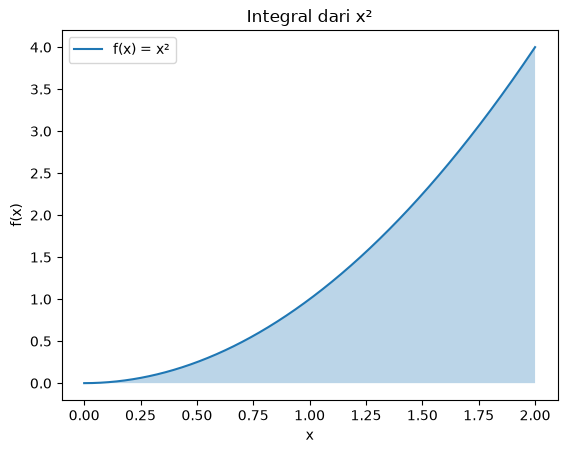

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y, label="f(x) = x²")

plt.fill_between(x, y, alpha=0.3)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Integral dari x²")
plt.legend()

plt.show()

### Visualisasi Trapezoidal Rule

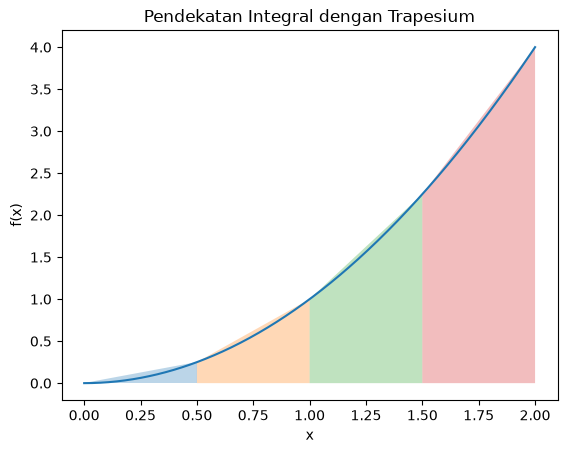

In [16]:
def f(x):
    return x**2

a = 0
b = 2
N = 4

h = (b - a) / N

x = np.linspace(a, b, 500)
y = f(x)

plt.plot(x, y)

for i in range(N):
    x0 = a + i * h
    x1 = x0 + h

    y0 = f(x0)
    y1 = f(x1)

    plt.fill(
        [x0, x1, x1, x0],
        [0,   0, y1, y0],
        alpha=0.3
    )

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Pendekatan Integral dengan Trapesium")

plt.show()

# **11. Implementasi dengan NumPy dan SciPy**

In [17]:
import numpy as np

def trapezoidal_numpy(f, a, b, N):
    x = np.linspace(a, b, N+1)
    y = f(x)

    h = (b - a) / N

    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])

def f(x):
    return x**2

hasil = trapezoidal_numpy(f, 0, 2, 1000)

print(hasil)

2.6666679999999996


In [18]:
from scipy.integrate import quad

def f(x):
    return x**2

hasil, error = quad(f, 0, 2)

print(f"Integral = {hasil}")
print(f"Error    = {error}")

Integral = 2.666666666666667
Error    = 2.960594732333751e-14


# **12. Contoh Fisika**

### **Menghitung Usaha**

Usaha didefinisikan sebagai:

$$ W = \int_{x1}^{x2} F(x) \ dx $$

Misalkan gaya:

$$ F(x) = kx^2 $$

dengan $k = 10 N/m^2$ dan objek berpindah dari $x = 0$ hingga $x=2\text{ m}$

Maka:

$$ W = \int_{0}^{2} 10x^2 \ dx $$

In [20]:
def F(x):
    k = 10
    return k * x**2

W = simpson_rule(F, 0, 2, 100)

print(f"Usaha = {W:.4f} J")

Usaha = 26.6667 J


Secara analitik:

$$W = 10 \left[ \frac{x^3}{3} \right]_0^2$$

sehingga:

$$W = \frac{80}{3}$$

atau sekitar:

$$26.6667 \text{ J.}$$

### **Massa Benda**

Misalkan rapat massa suatu batang tidak konstan:

$$ \rho(x) = 2 + x^2 $$

dengan panjang:

$$ L = 5 \ m $$

Massa:

$$ m = \int_{0}^{L} \rho(x) A \ dx $$

Misalkan luas penampang $ A = 0.01 \ m^2$

In [23]:
def density(x):
    return 2 + x**2

A = 0.01
L = 5

def integrand(x):
    return density(x) * A

mass = simpson_rule(integrand, 0, L, 100)

print(f"Massa = {mass:.4f} kg")

Massa = 0.5167 kg


Di sini integral numerik digunakan karena kita tidak langsung menghitung luas seluruh massa sekaligus; distribusi massa berubah terhadap posisi.

### **Nilai Ekspektasi Mekanika Kuantum**

Dalam mekanika kuantum:

$$\langle x \rangle = \int_{-\infty}^{\infty} x |\psi(x)|^2 \, dx.$$

Untuk contoh sederhana, kita gunakan fungsi gelombang Gaussian:

$$\psi(x) = \frac{1}{\sqrt[4]{\pi}} e^{-x^2/2}.$$

Kita dapat menghitung aproksimasi:

$$\langle x \rangle$$

pada interval yang cukup besar, misalnya:

$$-5 \le x \le 5.$$

In [26]:
import numpy as np

def psi(x):
    return (1 / np.pi**0.25) * np.exp(-x**2 / 2)

def expectation_integrand(x):
    return x * abs(psi(x))**2

hasil = simpson_rule(expectation_integrand, -5, 5, 1000)

print(f"<x> = {hasil:.10f}")

<x> = 0.0000000000


Hasilnya mendekati:

$$ \boxed{\langle x \rangle = 0} $$

yang sesuai dengan simetri fungsi gelombang.

# **13. Contoh Integral yang Tidak Memiliki Antiturunan Sederhana**

Pertimbangkan:

$$ I = \int_{0}^{1} e^{-x^2}\ dx $$

Integral ini tidak memiliki antiturunan elementer sederhana.

In [27]:
import numpy as np

def f(x):
    return np.exp(-x**2)

hasil = simpson_rule(f, 0, 1, 1000)

print(hasil)

0.746824132812436


In [28]:
from scipy.integrate import quad

def f(x):
    return np.exp(-x**2)

hasil, error = quad(f, 0, 1)

print(f"Integral = {hasil}")
print(f"Error    = {error}")

Integral = 0.7468241328124271
Error    = 8.291413475940725e-15
